In [1]:
!pip install transformers datasets scikit-learn torch pandas numpy -q

In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: Tesla T4


In [ ]:

df = pd.read_csv(
    '/content/Phishing_Email.csv',
    engine='python',
    on_bad_lines='skip'     
)

print(f"Shape after loading: {df.shape}")
df.head()

Shape after loading: (20698, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
print("Columns:", df.columns.tolist())
print("\nRaw value counts:\n", df['Email Type'].value_counts(dropna=False))


df = df.rename(columns={'Email Text': 'text', 'Email Type': 'label'})


df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']
df = df[df['text'].str.lower() != 'empty']


df['label'] = df['label'].str.strip()

print(f"\nShape after cleaning: {df.shape}")
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nLabel %:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

Columns: ['Unnamed: 0', 'Email Text', 'Email Type']

Raw value counts:
 Email Type
Safe Email               11319
Phishing Email            7328
None                      2049
 nur ein Arbeitsloser        1
 penguins                    1
Name: count, dtype: int64

Shape after cleaning: (18097, 3)

Label distribution:
label
Safe Email              11121
Phishing Email           6974
nur ein Arbeitsloser        1
penguins                    1
Name: count, dtype: int64

Label %:
label
Safe Email              61.45
Phishing Email          38.54
nur ein Arbeitsloser     0.01
penguins                 0.01
Name: proportion, dtype: float64


In [ ]:

label_map = {'Safe Email': 0, 'Phishing Email': 1}
df['label_enc'] = df['label'].map(label_map)


df = df.dropna(subset=['label_enc'])
df['label_enc'] = df['label_enc'].astype(int)

print("After encoding:")
print(df['label_enc'].value_counts())

safe = df[df['label_enc'] == 0]
phish = df[df['label_enc'] == 1]

min_count = min(len(safe), len(phish))
print(f"\nBalancing to {min_count} samples per class")

safe_bal = safe.sample(n=min_count, random_state=42)
phish_bal = phish.sample(n=min_count, random_state=42)

df_balanced = pd.concat([safe_bal, phish_bal]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print("Balanced label counts:")
print(df_balanced['label_enc'].value_counts())

After encoding:
label_enc
0    11121
1     6974
Name: count, dtype: int64

Balancing to 6974 samples per class

Balanced dataset shape: (13948, 4)
Balanced label counts:
label_enc
0    6974
1    6974
Name: count, dtype: int64


In [7]:
# 70% train, 15% val, 15% test
X = df_balanced['text'].values
y = df_balanced['label_enc'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size : {len(X_train)}")
print(f"  Safe=0   : {Counter(y_train)[0]}")
print(f"  Phish=1  : {Counter(y_train)[1]}")

print(f"\nVal size   : {len(X_val)}")
print(f"  Safe=0   : {Counter(y_val)[0]}")
print(f"  Phish=1  : {Counter(y_val)[1]}")

print(f"\nTest size  : {len(X_test)}")
print(f"  Safe=0   : {Counter(y_test)[0]}")
print(f"  Phish=1  : {Counter(y_test)[1]}")

Train size : 9763
  Safe=0   : 4881
  Phish=1  : 4882

Val size   : 2092
  Safe=0   : 1046
  Phish=1  : 1046

Test size  : 2093
  Safe=0   : 1047
  Phish=1  : 1046


In [ ]:
MODEL_NAME = 'roberta-base'
MAX_LEN = 256  

tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmailDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = EmailDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer, MAX_LEN)

BATCH_SIZE = 16  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 611
Val batches  : 131
Test batches : 131


In [9]:
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)
print("Model loaded on", device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda
Parameters: 124,647,170


In [10]:
EPOCHS = 4
LR = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

Total steps  : 2444
Warmup steps : 244


In [11]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_roberta_phishing.pt')
        print(f"  ✅ Best model saved (val_acc={val_acc:.4f})")

Epoch 1/4 | Train Loss: 0.2020 Acc: 0.9064 | Val Loss: 0.0815 Acc: 0.9837
  ✅ Best model saved (val_acc=0.9837)
Epoch 2/4 | Train Loss: 0.0417 Acc: 0.9912 | Val Loss: 0.0648 Acc: 0.9876
  ✅ Best model saved (val_acc=0.9876)
Epoch 3/4 | Train Loss: 0.0141 Acc: 0.9969 | Val Loss: 0.0778 Acc: 0.9885
  ✅ Best model saved (val_acc=0.9885)
Epoch 4/4 | Train Loss: 0.0027 Acc: 0.9993 | Val Loss: 0.0692 Acc: 0.9895
  ✅ Best model saved (val_acc=0.9895)


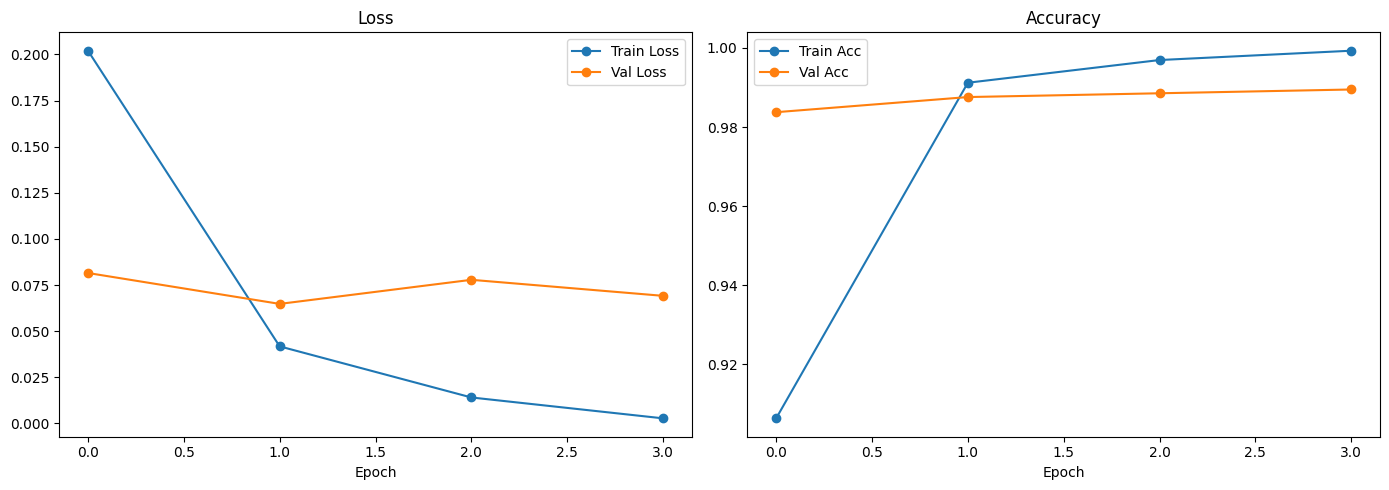

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'],   label='Val Loss',   marker='o')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'],   label='Val Acc',   marker='o')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

TEST SET EVALUATION
                precision    recall  f1-score   support

    Safe Email       0.98      0.99      0.98      1047
Phishing Email       0.99      0.98      0.98      1046

      accuracy                           0.98      2093
     macro avg       0.98      0.98      0.98      2093
  weighted avg       0.98      0.98      0.98      2093



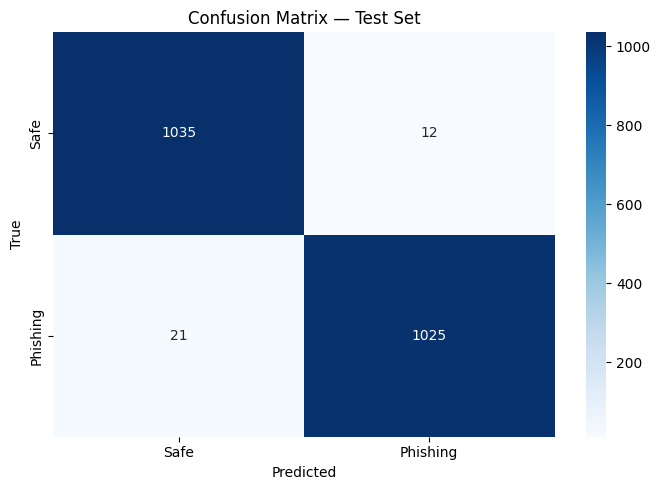

In [ ]:

model.load_state_dict(torch.load('best_roberta_phishing.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Safe Email', 'Phishing Email']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [14]:
import os
SAVE_DIR = '/content/roberta_phishing_model'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model and tokenizer saved to {SAVE_DIR}")
print("Files:", os.listdir(SAVE_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/roberta_phishing_model
Files: ['config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


In [ ]:
def predict_email(text, model, tokenizer, device, max_len=256):
    model.eval()
    enc = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred  = probs.argmax()

    label_map_inv = {0: 'Safe Email', 1: 'Phishing Email'}
    print(f"Prediction : {label_map_inv[pred]}")
    print(f"Safe prob  : {probs[0]:.4f}")
    print(f"Phish prob : {probs[1]:.4f}")
    return label_map_inv[pred], probs


predict_email("Congratulations! You've won a $1000 gift card. Click here now!", model, tokenizer, device)
predict_email("Hi team, please find the Q3 report attached. Let me know if you have questions.", model, tokenizer, device)

Prediction : Phishing Email
Safe prob  : 0.0001
Phish prob : 0.9999
Prediction : Safe Email
Safe prob  : 1.0000
Phish prob : 0.0000


('Safe Email', array([9.9996376e-01, 3.6213969e-05], dtype=float32))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')
roc_auc   = roc_auc_score(all_labels, all_preds)

print("=" * 50)
print("       FINAL TEST SET METRICS SUMMARY")
print("=" * 50)
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (W)   : {precision:.4f}")
print(f"  Recall    (W)   : {recall:.4f}")
print(f"  F1 Score  (W)   : {f1:.4f}")
print(f"  ROC-AUC         : {roc_auc:.4f}")
print("=" * 50)


print("\nPer-Class Breakdown:")
print(f"  {'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 55)
for i, cls in enumerate(['Safe Email', 'Phishing Email']):
    p = precision_score(all_labels, all_preds, labels=[i], average='micro')
    r = recall_score(all_labels, all_preds, labels=[i], average='micro')
    f = f1_score(all_labels, all_preds, labels=[i], average='micro')
    s = sum(1 for l in all_labels if l == i)
    print(f"  {cls:<20} {p:>10.4f} {r:>10.4f} {f:>10.4f} {s:>10}")

       FINAL TEST SET METRICS SUMMARY
  Accuracy        : 0.9842  (98.42%)
  Precision (W)   : 0.9843
  Recall    (W)   : 0.9842
  F1 Score  (W)   : 0.9842
  ROC-AUC         : 0.9842

Per-Class Breakdown:
  Class                 Precision     Recall         F1    Support
-------------------------------------------------------
  Safe Email               0.9801     0.9885     0.9843       1047
  Phishing Email           0.9884     0.9799     0.9842       1046


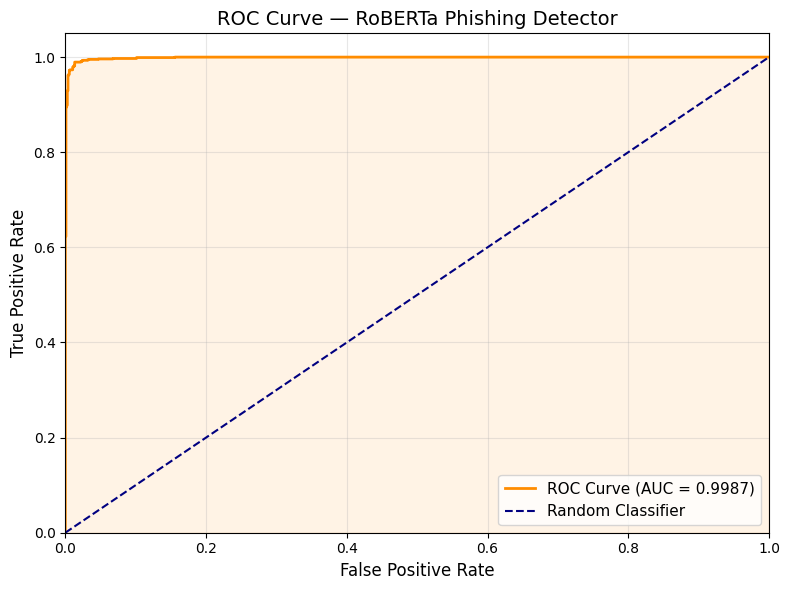

AUC Score: 0.9987


In [ ]:
from sklearn.metrics import roc_curve, auc


all_probs = []
model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.extend(probs[:, 1])   # phishing probability

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — RoBERTa Phishing Detector', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f"AUC Score: {roc_auc_val:.4f}")

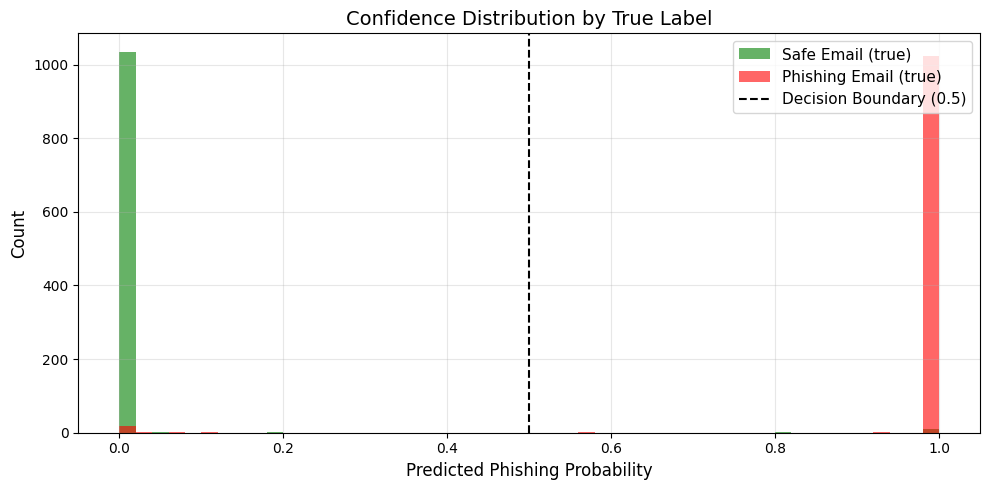

In [18]:
all_probs_np = np.array(all_probs)
all_labels_np = np.array(all_labels)

safe_probs  = all_probs_np[all_labels_np == 0]   # phishing prob for safe emails (should be low)
phish_probs = all_probs_np[all_labels_np == 1]   # phishing prob for phishing emails (should be high)

plt.figure(figsize=(10, 5))
plt.hist(safe_probs,  bins=50, alpha=0.6, color='green', label='Safe Email (true)')
plt.hist(phish_probs, bins=50, alpha=0.6, color='red',   label='Phishing Email (true)')
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision Boundary (0.5)')
plt.xlabel('Predicted Phishing Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Confidence Distribution by True Label', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150)
plt.show()

In [ ]:

test_texts = list(X_test)

misclassified = []
for i, (true, pred, prob) in enumerate(zip(all_labels, all_preds, all_probs)):
    if true != pred:
        misclassified.append({
            'index'     : i,
            'text'      : test_texts[i][:120] + '...',
            'true_label': 'Safe' if true == 0 else 'Phishing',
            'pred_label': 'Safe' if pred == 0 else 'Phishing',
            'phish_prob': round(prob, 4)
        })

print(f"Total misclassified: {len(misclassified)} / {len(all_labels)}")
print(f"Error rate: {len(misclassified)/len(all_labels)*100:.2f}%\n")

mis_df = pd.DataFrame(misclassified)
if len(mis_df) > 0:
    print("Sample misclassified emails:")
    print(mis_df[['true_label', 'pred_label', 'phish_prob', 'text']].head(10).to_string(index=False))

Total misclassified: 33 / 2093
Error rate: 1.58%

Sample misclassified emails:
true_label pred_label  phish_prob                                                                                                                          text
      Safe   Phishing      0.9969   market price volatility may 1 - 3 houston market price volatility may 1 - 3 , 2002 o houston , tx click here to download...
      Safe   Phishing      0.9999 \nWe have extended our Free seat sale until Thursday 21st November\nFor details see http://www.ryanair.com****************...
  Phishing       Safe      0.0129   security update : wellsfargo . com urent - issue lx security key : qzskpjakjit dear wells fargo customer , during our re...
      Safe   Phishing      0.9999   spring savings certificate - take 30 % off save 30 % when you use our customer appreciation spring savings certificate a...
  Phishing       Safe      0.0027   sitescooper : scoop websites onto your palmpilot - sitescooper automatically retrieve

In [ ]:
def predict_batch(email_list, model, tokenizer, device, max_len=256, batch_size=16):
    model.eval()
    results = []

    for i in range(0, len(email_list), batch_size):
        batch_texts = email_list[i:i+batch_size]
        enc = tokenizer(
            batch_texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()

        for text, prob in zip(batch_texts, probs):
            results.append({
                'text'      : text[:80] + '...' if len(text) > 80 else text,
                'prediction': 'Phishing Email' if prob[1] > 0.5 else 'Safe Email',
                'safe_prob' : round(float(prob[0]), 4),
                'phish_prob': round(float(prob[1]), 4)
            })

    return pd.DataFrame(results)



test_emails = [
    "Dear user, your account has been suspended. Click here to verify immediately.",
    "Hi John, the meeting is rescheduled to 3pm tomorrow. Please update your calendar.",
    "You have been selected as a winner! Claim your $500 prize now. Limited time offer!",
    "Please find attached the monthly expense report for your review.",
    "URGENT: Your bank account will be closed. Provide your details within 24 hours.",
    "Team standup notes from today — action items in the doc linked below.",
]

results_df = predict_batch(test_emails, model, tokenizer, device)
print(results_df.to_string(index=False))

                                                                               text     prediction  safe_prob  phish_prob
      Dear user, your account has been suspended. Click here to verify immediately. Phishing Email     0.0001      0.9999
Hi John, the meeting is rescheduled to 3pm tomorrow. Please update your calendar...     Safe Email     1.0000      0.0000
You have been selected as a winner! Claim your $500 prize now. Limited time offe... Phishing Email     0.0000      1.0000
                   Please find attached the monthly expense report for your review.     Safe Email     1.0000      0.0000
    URGENT: Your bank account will be closed. Provide your details within 24 hours. Phishing Email     0.0001      0.9999
              Team standup notes from today — action items in the doc linked below.     Safe Email     1.0000      0.0000


In [ ]:
import zipfile, os


with open('/content/metrics_summary.txt', 'w') as f:
    f.write("RoBERTa Phishing Email Classifier — Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"ROC-AUC   : {roc_auc_val:.4f}\n")
    f.write("=" * 50 + "\n")
    f.write(f"Train size: {len(X_train)}\n")
    f.write(f"Val size  : {len(X_val)}\n")
    f.write(f"Test size : {len(X_test)}\n")
    f.write(f"Misclassified: {len(misclassified)}\n")


zip_path = '/content/roberta_phishing_complete.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    
    for f in os.listdir('/content/roberta_phishing_model'):
        zf.write(f'/content/roberta_phishing_model/{f}', f'model/{f}')
    
    for fname in ['training_curves.png', 'confusion_matrix.png',
                  'roc_curve.png', 'confidence_distribution.png']:
        if os.path.exists(f'/content/{fname}'):
            zf.write(f'/content/{fname}', fname)
    
    zf.write('/content/metrics_summary.txt', 'metrics_summary.txt')

print(f"Everything saved to: {zip_path}")
print(f"Zip size: {os.path.getsize(zip_path)/1024/1024:.2f} MB")


from google.colab import files
files.download(zip_path)

Everything saved to: /content/roberta_phishing_complete.zip
Zip size: 479.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>